# Anime Data Science

In [1]:
print("Anime Data Science!")

Anime Data Science!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
anime_data = pd.read_csv('animes.csv')
anime_data.head()

,animeID,title,alternative_title,type,year,score,episodes,mal_url,sequel,image_url,genres,genres_detailed
0,1,Howl's Moving Castle,Howl no Ugoku Shiro,MOVIE,2004,8.41,1,https://myanimelist.net/anime/431,False,https://cdn.myanimelist.net/images/anime/1470/...,"['Adventure', 'Award Winning', 'Drama', 'Fanta...","['action', 'adventure', 'age gap', 'air force'..."
1,2,Death Note,NaN,TV,2006,8.63,37,https://myanimelist.net/anime/1535,False,https://cdn.myanimelist.net/images/anime/1079/...,"['Supernatural', 'Suspense']","['achronological order', 'acting', 'adapted in..."
2,3,Problem Children Are Coming from Another World...,Mondaiji-tachi ga Isekai kara Kuru Sou desu yo?,TV,2013,7.42,10,https://myanimelist.net/anime/15315,False,https://cdn.myanimelist.net/images/anime/12/43...,"['Action', 'Comedy', 'Fantasy']","['action', 'alternative world', 'anthropomorph..."
3,4,BTOOOM!,Btooom!,TV,2012,7.34,12,https://myanimelist.net/anime/14345,False,https://cdn.myanimelist.net/images/anime/4/409...,"['Action', 'Sci-Fi', 'Suspense']","['achronological order', 'action', 'adventure'..."
4,5,Sword Art Online,NaN,TV,2012,7.5,25,https://myanimelist.net/anime/11757,False,https://cdn.myanimelist.net/images/anime/11/39...,"['Action', 'Adventure', 'Fantasy', 'Romance']","['action', 'action drama', 'adventure', 'alter..."


In [4]:
anime_data.size

242844

In [5]:
special_char_pattern = r'[^a-zA-Z0-9\s]'

# Identify rows with blank values (empty string or NaN) or special characters
# Use ~ to invert the boolean mask, keeping rows that *don't* match the conditions
anime_data = anime_data[~((anime_data['year'].astype(str).str.strip() == '') |  # Empty strings after stripping whitespace
                   (anime_data['year'].isna()) |                       # NaN values
                   (anime_data['year'].astype(str).str.contains(special_char_pattern, na=False)))] # Special characters


In [6]:
anime_data[anime_data['year'] == '?']

,animeID,title,alternative_title,type,year,score,episodes,mal_url,sequel,image_url,genres,genres_detailed


In [7]:
anime_data = anime_data[anime_data['year'].astype(int) <= 2025]

In [8]:
# anime_data = anime_data.drop(columns=['alternative_title', 'mal_url', 'score', 'image_url'])
# anime_data.head()

In [9]:
ratings_data = pd.read_csv('ratings.csv')
ratings_data.head()

,userID,animeID,rating
0,1,1,10
1,1,2,10
2,1,3,7
3,1,4,10
4,1,5,10


In [10]:
agg_ratings_data = ratings_data.groupby('animeID').agg({'rating': ['mean', 'count']})
agg_ratings_data.head()

rating        
             mean   count
animeID                  
1        8.524016  312641
2        8.493181  854856
3        7.340694   80973
4        7.124142  120217
5        7.161983  534853

In [11]:
# Overall weighted average rating across all anime
# Uses mean rating per anime (agg_ratings_data['rating','mean']) weighted by its count (agg_ratings_data['rating','count'])

if 'agg_ratings_data' not in globals():
    raise NameError("agg_ratings_data not found. Run the aggregation cell first.")

# Access the columns from the MultiIndex
mean_col = ('rating','mean')
count_col = ('rating','count')

if mean_col not in agg_ratings_data.columns or count_col not in agg_ratings_data.columns:
    raise KeyError("Expected MultiIndex columns ('rating','mean') and ('rating','count') in agg_ratings_data.")

# Compute weighted average: sum(mean * count) / sum(count)
total_count = agg_ratings_data[count_col].sum()
weighted_sum = (agg_ratings_data[mean_col] * agg_ratings_data[count_col]).sum()
weighted_avg_rating = weighted_sum / total_count if total_count else float('nan')

print(f"Overall weighted average rating: {weighted_avg_rating:.4f}")

Overall weighted average rating: 7.6451


In [12]:
# Flatten the MultiIndex columns in agg_ratings_data
agg_ratings_flat = agg_ratings_data.copy()
agg_ratings_flat.columns = ['_'.join(col) for col in agg_ratings_flat.columns]
anime_with_ratings = anime_data.merge(agg_ratings_flat, left_on='animeID', right_index=True)
anime_with_ratings.head()

,animeID,title,alternative_title,type,year,score,episodes,mal_url,sequel,image_url,genres,genres_detailed,rating_mean,rating_count
0,1,Howl's Moving Castle,Howl no Ugoku Shiro,MOVIE,2004,8.41,1,https://myanimelist.net/anime/431,False,https://cdn.myanimelist.net/images/anime/1470/...,"['Adventure', 'Award Winning', 'Drama', 'Fanta...","['action', 'adventure', 'age gap', 'air force'...",8.524016,312641
1,2,Death Note,NaN,TV,2006,8.63,37,https://myanimelist.net/anime/1535,False,https://cdn.myanimelist.net/images/anime/1079/...,"['Supernatural', 'Suspense']","['achronological order', 'acting', 'adapted in...",8.493181,854856
2,3,Problem Children Are Coming from Another World...,Mondaiji-tachi ga Isekai kara Kuru Sou desu yo?,TV,2013,7.42,10,https://myanimelist.net/anime/15315,False,https://cdn.myanimelist.net/images/anime/12/43...,"['Action', 'Comedy', 'Fantasy']","['action', 'alternative world', 'anthropomorph...",7.340694,80973
3,4,BTOOOM!,Btooom!,TV,2012,7.34,12,https://myanimelist.net/anime/14345,False,https://cdn.myanimelist.net/images/anime/4/409...,"['Action', 'Sci-Fi', 'Suspense']","['achronological order', 'action', 'adventure'...",7.124142,120217
4,5,Sword Art Online,NaN,TV,2012,7.5,25,https://myanimelist.net/anime/11757,False,https://cdn.myanimelist.net/images/anime/11/39...,"['Action', 'Adventure', 'Fantasy', 'Romance']","['action', 'action drama', 'adventure', 'alter...",7.161983,534853


In [13]:
# Create primary_genre from genres_detailed
import ast

def extract_primary(gen):
    if pd.isna(gen):
        return None
    # If already a list
    if isinstance(gen, list):
        return gen[0] if gen else None
    if isinstance(gen, str):
        s = gen.strip()
        # Try list literal first
        if s.startswith('[') and s.endswith(']'):
            try:
                val = ast.literal_eval(s)
                if isinstance(val, list) and val:
                    return val[0]
            except Exception:
                pass
        # Fallback: split by comma
        parts = [p.strip() for p in s.split(',') if p.strip()]
        return parts[0] if parts else None
    return None

if 'anime_with_ratings' not in globals():
    raise NameError("anime_with_ratings not found. Run previous data prep cells first (imports, load anime, drop cols, load ratings, aggregate, merge).")

if 'genres_detailed' not in anime_with_ratings.columns:
    raise KeyError("Column 'genres_detailed' not found in anime_with_ratings. Verify animes.csv contains it and rerun load/merge.")

anime_with_ratings['primary_genre'] = anime_with_ratings['genres_detailed'].apply(extract_primary)
anime_with_ratings[['animeID','primary_genre','genres_detailed']].head()

,animeID,primary_genre,genres_detailed
0,1,action,"['action', 'adventure', 'age gap', 'air force'..."
1,2,achronological order,"['achronological order', 'acting', 'adapted in..."
2,3,action,"['action', 'alternative world', 'anthropomorph..."
3,4,achronological order,"['achronological order', 'action', 'adventure'..."
4,5,action,"['action', 'action drama', 'adventure', 'alter..."


/var/folders/n5/md8pk9253rg5s5w7t_bg6_lm0000gn/T/ipykernel_59098/627782886.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_genres, x='weighted_avg_rating', y='primary_genre', palette='viridis')


,primary_genre,weighted_sum,total_count,n_titles,weighted_avg_rating
56,adventure,28573364.0,3614264,1289,7.905721
52,adult cast,15754339.0,2024768,197,7.780812
38,achromatic,4470917.0,576179,207,7.759597
32,absurdist humour,75748967.0,9851495,392,7.689083
42,acting,19727285.0,2572040,167,7.669898


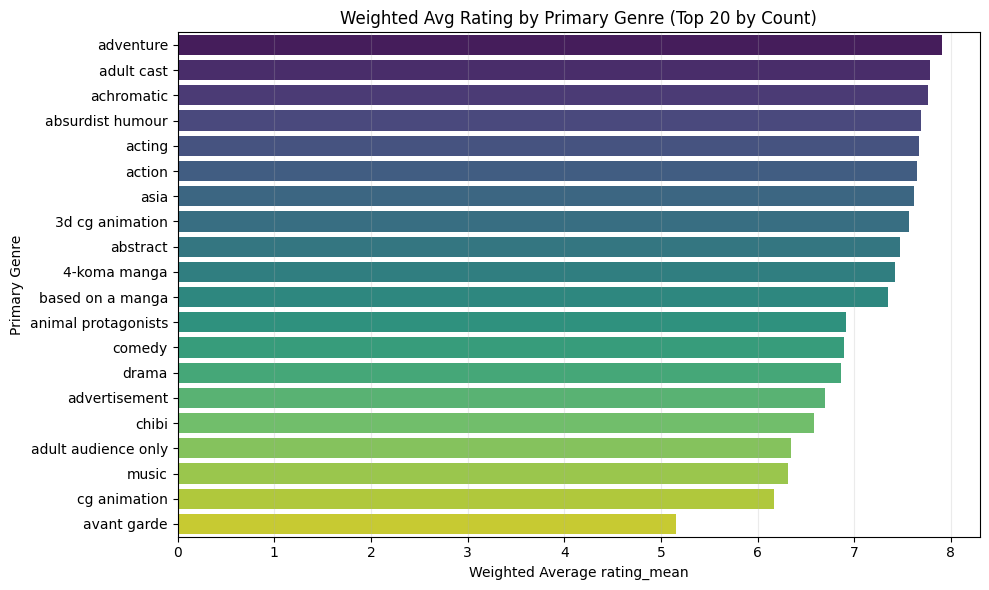

In [14]:
# Compare average rating_mean by primary_genre
# We'll aggregate, show top genres by count, and plot average ratings.

if 'anime_with_ratings' not in globals():
    raise NameError("anime_with_ratings not found. Run earlier data prep cells first.")

if 'primary_genre' not in anime_with_ratings.columns:
    raise KeyError("primary_genre not found. Run the cell that creates it.")

genre_stats = (
    anime_with_ratings
        .dropna(subset=['primary_genre', 'rating_mean', 'rating_count'])
        .assign(weighted_contrib=lambda df: df['rating_mean'] * df['rating_count'])
        .groupby('primary_genre', as_index=False)
        .agg(
            weighted_sum=('weighted_contrib', 'sum'),
            total_count=('rating_count', 'sum'),
            n_titles=('primary_genre', 'count')
        )
)

genre_stats['weighted_avg_rating'] = genre_stats['weighted_sum'] / genre_stats['total_count']

# Sort genres by number of titles (popularity proxy)
genre_stats = genre_stats.sort_values('n_titles', ascending=False)

# Top 20 by title count, then sort those by weighted average rating
plot_genres = genre_stats.head(20).sort_values('weighted_avg_rating', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_genres, x='weighted_avg_rating', y='primary_genre', palette='viridis')
plt.title('Weighted Avg Rating by Primary Genre (Top 20 by Count)')
plt.xlabel('Weighted Average rating_mean')
plt.ylabel('Primary Genre')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()

# Display summary table
plot_genres[['primary_genre', 'weighted_avg_rating', 'n_titles', 'total_count']].head()
plot_genres.head()

#### See how often each genre comes up in the 'genres' column 

Total unique genres: 2987
Top 10 genres:
                 genre  count
0  japanese production  11003
1               comedy  10015
2               action   7905
3              fantasy   7319
4              present   7001
5                drama   6056
6            adventure   5602
7                place   5389
8              romance   4891
9  speculative fiction   4812


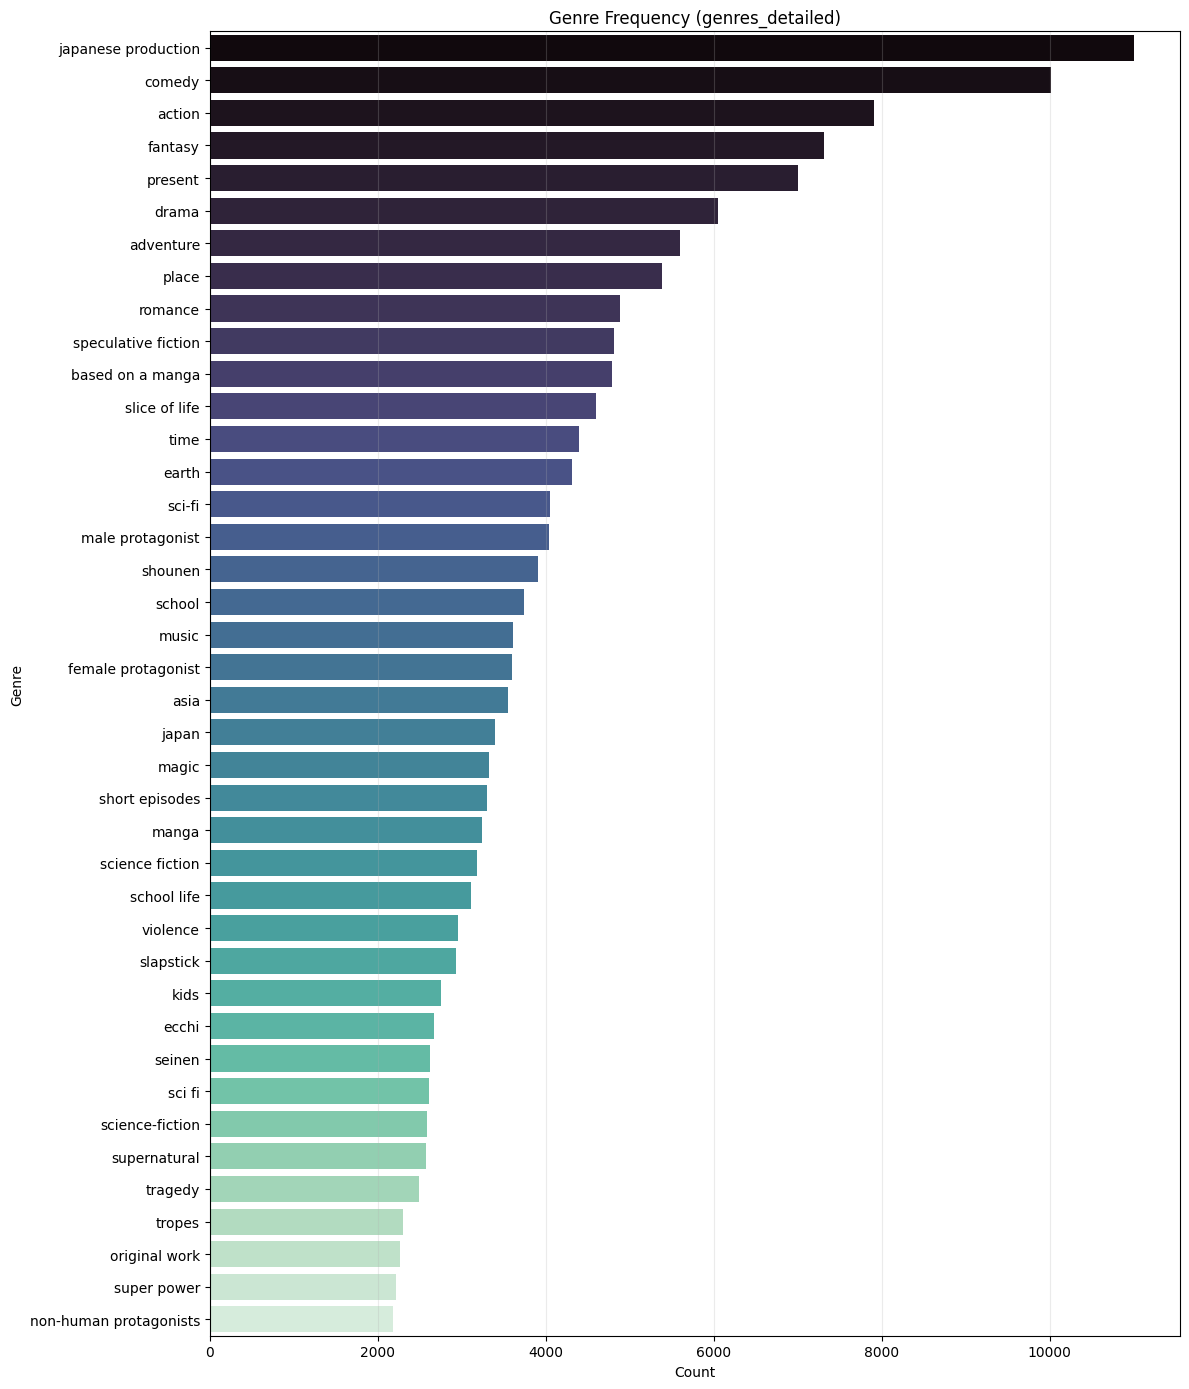

,genre,count
0,japanese production,11003
1,comedy,10015
2,action,7905
3,fantasy,7319
4,present,7001


In [15]:
# Extract all genres from genres_detailed, count them, and visualize
import re
import ast
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Choose the dataframe that has genres_detailed
if 'anime_with_ratings' in globals() and 'genres_detailed' in anime_with_ratings.columns:
    _df = anime_with_ratings
elif 'anime_data' in globals() and 'genres_detailed' in anime_data.columns:
    _df = anime_data
else:
    raise KeyError("No DataFrame with 'genres_detailed' column found. Run earlier data prep cells first.")

# Robust parser for a single cell's genres value
def parse_genres(val):
    if pd.isna(val):
        return []
    if isinstance(val, list):
        return [str(g).strip() for g in val if str(g).strip()]
    if isinstance(val, str):
        s = val.strip()
        # Attempt list literal first (e.g. "['Action', 'Comedy']")
        if s.startswith('[') and s.endswith(']'):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [str(g).strip() for g in parsed if str(g).strip()]
            except Exception:
                pass  # fall back to regex splitting
        # Split by comma or pipe or semicolon as delimiters
        parts = re.split(r'[|,;]', s)
        return [p.strip() for p in parts if p.strip()]
    return []

# Apply parser to every row
_genre_lists = _df['genres_detailed'].apply(parse_genres)
all_genres = [g for sub in _genre_lists for g in sub]

# Basic cleanup: lowercase and strip, remove trivial tokens
stop_tokens = {"", "and", "the"}
all_genres = [g.lower() for g in all_genres if g.lower() not in stop_tokens]

# Frequency counts
genre_counts = Counter(all_genres)
genre_count_df = (pd.DataFrame(genre_counts.items(), columns=['genre', 'count'])
                  .sort_values('count', ascending=False)
                  .reset_index(drop=True))

print(f"Total unique genres: {genre_count_df.shape[0]}")
print("Top 10 genres:")
print(genre_count_df.head(10))

# Plot (limit to top N if very large)
TOP_N = 40  # adjust if needed
plot_df = genre_count_df.head(TOP_N)
plt.figure(figsize=(12, 0.3 * TOP_N + 2))
# Provide hue to avoid future deprecation warning
sns.barplot(data=plot_df, x='count', y='genre', hue='genre', palette='mako', dodge=False, legend=False)
plt.title('Genre Frequency (genres_detailed)')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

# Display full DataFrame head for quick inspection
genre_count_df.head()

,year,mean_rating,total_count,weighted_sum,weighted_avg_rating
0,1907,5.255393,2318,12182.0,5.255393
1,1917,4.884358,3165,15861.0,5.011374
2,1918,4.466046,775,3360.0,4.335484
3,1920,4.466667,15,67.0,4.466667
4,1922,5.000000,1,5.0,5.000000


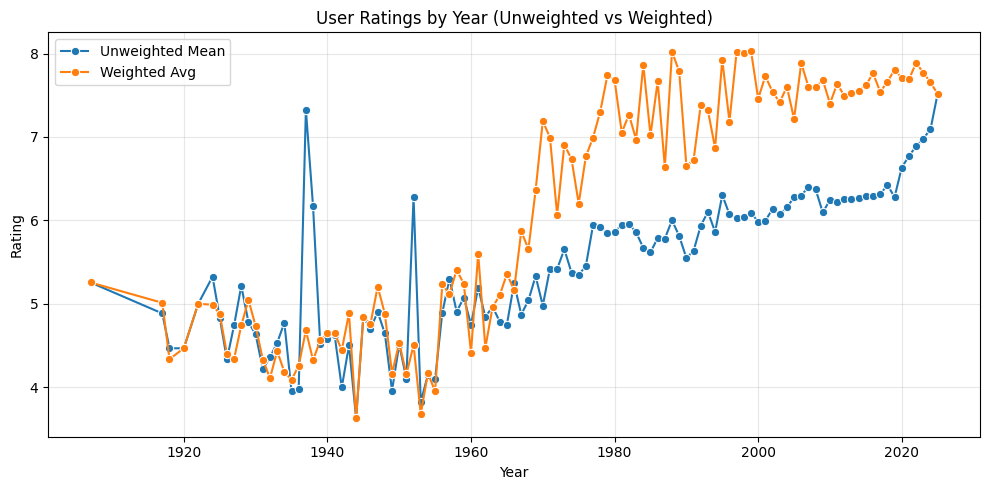

In [16]:
# Average rating by year (adds weighted average using rating_count)
if 'anime_with_ratings' not in globals():
    raise NameError("anime_with_ratings not found. Run earlier data prep cells first.")

for col in ['year', 'rating_mean', 'rating_count']:
    if col not in anime_with_ratings.columns:
        raise KeyError(f"Required column {col} missing in anime_with_ratings.")

year_df = anime_with_ratings[['year', 'rating_mean', 'rating_count']].copy()
year_df = year_df.dropna(subset=['year', 'rating_mean', 'rating_count'])
year_df['year'] = pd.to_numeric(year_df['year'], errors='coerce')
year_df = year_df.dropna(subset=['year'])
year_df['year'] = year_df['year'].astype(int)

year_df = year_df.assign(weighted_contrib=lambda d: d['rating_mean'] * d['rating_count'])

yearly = (
    year_df
        .groupby('year', as_index=False)
        .agg(
            mean_rating=('rating_mean', 'mean'),
            total_count=('rating_count', 'sum'),
            weighted_sum=('weighted_contrib', 'sum')
        )
        .assign(weighted_avg_rating=lambda d: d['weighted_sum'] / d['total_count'])
        .sort_values('year')
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly, x='year', y='mean_rating', marker='o', label='Unweighted Mean')
sns.lineplot(data=yearly, x='year', y='weighted_avg_rating', marker='o', label='Weighted Avg')
plt.title('User Ratings by Year (Unweighted vs Weighted)')
plt.xlabel('Year')
plt.ylabel('Rating')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

yearly.head()

In [17]:
yearly.tail()

,year,mean_rating,total_count,weighted_sum,weighted_avg_rating
102,2021,6.770604,7652294,58844350.0,7.689766
103,2022,6.889370,5603282,44200194.0,7.888269
104,2023,6.980675,4321537,33587319.0,7.772077
105,2024,7.090976,2641852,20225488.0,7.655799
106,2025,7.518992,153550,1154043.0,7.515747


## Clustering EDA 

### KMeans

In [18]:
anime_data.head()

,animeID,title,alternative_title,type,year,score,episodes,mal_url,sequel,image_url,genres,genres_detailed
0,1,Howl's Moving Castle,Howl no Ugoku Shiro,MOVIE,2004,8.41,1,https://myanimelist.net/anime/431,False,https://cdn.myanimelist.net/images/anime/1470/...,"['Adventure', 'Award Winning', 'Drama', 'Fanta...","['action', 'adventure', 'age gap', 'air force'..."
1,2,Death Note,NaN,TV,2006,8.63,37,https://myanimelist.net/anime/1535,False,https://cdn.myanimelist.net/images/anime/1079/...,"['Supernatural', 'Suspense']","['achronological order', 'acting', 'adapted in..."
2,3,Problem Children Are Coming from Another World...,Mondaiji-tachi ga Isekai kara Kuru Sou desu yo?,TV,2013,7.42,10,https://myanimelist.net/anime/15315,False,https://cdn.myanimelist.net/images/anime/12/43...,"['Action', 'Comedy', 'Fantasy']","['action', 'alternative world', 'anthropomorph..."
3,4,BTOOOM!,Btooom!,TV,2012,7.34,12,https://myanimelist.net/anime/14345,False,https://cdn.myanimelist.net/images/anime/4/409...,"['Action', 'Sci-Fi', 'Suspense']","['achronological order', 'action', 'adventure'..."
4,5,Sword Art Online,NaN,TV,2012,7.5,25,https://myanimelist.net/anime/11757,False,https://cdn.myanimelist.net/images/anime/11/39...,"['Action', 'Adventure', 'Fantasy', 'Romance']","['action', 'action drama', 'adventure', 'alter..."


In [19]:
anime_data = anime_data.drop(columns=['alternative_title', 'mal_url', 'score', 'image_url','genres_detailed'])
anime_data.head()

,animeID,title,type,year,episodes,sequel,genres
0,1,Howl's Moving Castle,MOVIE,2004,1,False,"['Adventure', 'Award Winning', 'Drama', 'Fanta..."
1,2,Death Note,TV,2006,37,False,"['Supernatural', 'Suspense']"
2,3,Problem Children Are Coming from Another World...,TV,2013,10,False,"['Action', 'Comedy', 'Fantasy']"
3,4,BTOOOM!,TV,2012,12,False,"['Action', 'Sci-Fi', 'Suspense']"
4,5,Sword Art Online,TV,2012,25,False,"['Action', 'Adventure', 'Fantasy', 'Romance']"


In [20]:
anime_data['type'].value_counts()

type
TV         5672
SPECIAL    4824
OVA        3651
MOVIE      3223
ONA        2699
Name: count, dtype: int64

In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

label_encoder = LabelEncoder()
anime_data['title'] = label_encoder.fit_transform(anime_data['title'])
anime_data['genres'] = label_encoder.fit_transform(anime_data['genres'])

one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
type_encoded = one_hot_encoder.fit_transform(anime_data[['type']])
type_encoded_df = pd.DataFrame(type_encoded, columns=one_hot_encoder.get_feature_names_out(['type']))
anime_data = pd.concat([anime_data.reset_index(drop=True), type_encoded_df.reset_index(drop=True)], axis=1)
anime_data = anime_data.drop(columns=['type'])

sequel_encoded = one_hot_encoder.fit_transform(anime_data[['sequel']])
sequel_encoded_df = pd.DataFrame(sequel_encoded, columns=one_hot_encoder.get_feature_names_out(['sequel']))
anime_data = pd.concat([anime_data.reset_index(drop=True), sequel_encoded_df.reset_index(drop=True)], axis=1)
anime_data = anime_data.drop(columns=['sequel'])

anime_data.head()


,animeID,title,year,episodes,genres,type_MOVIE,type_ONA,type_OVA,type_SPECIAL,type_TV,sequel_False,sequel_True
0,1,6991,2004,1,342,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,3535,2006,37,902,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,3,13333,2013,10,182,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,4,1392,2012,12,324,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,5,16117,2012,25,89,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(anime_data, test_size=0.2, random_state=47)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])

kmeans = KMeans(n_clusters=5, random_state=47, n_init='auto')
kmeans.fit(X_train_scaled)

# Attach cluster labels back to a copy of training dataframe
X_train = X_train.copy()
X_train['cluster'] = kmeans.labels_

print("Cluster counts:", X_train['cluster'].value_counts().to_dict())
print("Inertia:", kmeans.inertia_)
X_train.head()

Cluster counts: {1: 5831, 3: 3956, 0: 2902, 4: 2563, 2: 803}
Inertia: 81774.79451639258


,animeID,title,year,episodes,genres,type_MOVIE,type_ONA,type_OVA,type_SPECIAL,type_TV,sequel_False,sequel_True,cluster
8062,8066,12911,2023,1,656,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2
16239,16349,2340,2025,12,94,0.0,0.0,0.0,0.0,1.0,1.0,0.0,3
18023,18180,2649,2013,20,325,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1
9369,9381,6384,1998,31,394,0.0,0.0,0.0,0.0,1.0,1.0,0.0,3
9115,9127,2996,2017,1,890,1.0,0.0,0.0,0.0,0.0,1.0,0.0,4


#### Visualize Clusters

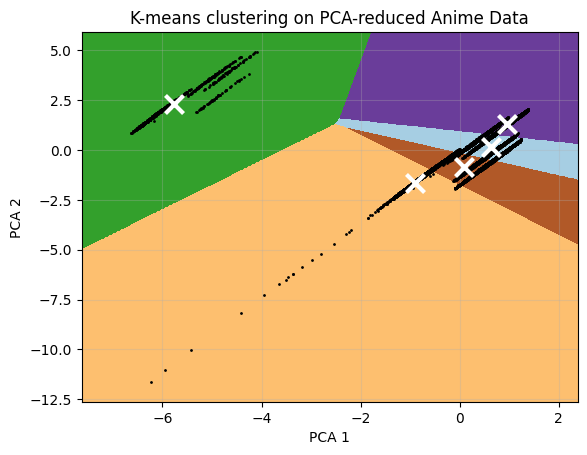

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit_transform(X_train_scaled)
pca_kmeans = KMeans(init='k-means++', n_clusters=5, random_state=47, n_init='auto').fit(pca)

h = 0.02  # step size in the mesh

x_min, x_max = pca[:, 0].min() - 1, pca[:, 0].max() + 1
y_min, y_max = pca[:, 1].min() - 1, pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = pca_kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(1)
plt.clf()
plt.imshow(Z, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap=plt.cm.Paired,
           aspect='auto', origin='lower')

plt.plot(pca[:, 0], pca[:, 1], 'k.', markersize=2)
centroids = pca_kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='x', s=169, linewidths=3,
            color='w', zorder=10)
plt.title('K-means clustering on PCA-reduced Anime Data')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(alpha=0.3)
plt.show()


## Use Cosine Similarity based on Genre(s) to recommend

In [24]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
anime_data = pd.read_csv('animes.csv')
anime_data.head()

,animeID,title,alternative_title,type,year,score,episodes,mal_url,sequel,image_url,genres,genres_detailed
0,1,Howl's Moving Castle,Howl no Ugoku Shiro,MOVIE,2004,8.41,1,https://myanimelist.net/anime/431,False,https://cdn.myanimelist.net/images/anime/1470/...,"['Adventure', 'Award Winning', 'Drama', 'Fanta...","['action', 'adventure', 'age gap', 'air force'..."
1,2,Death Note,NaN,TV,2006,8.63,37,https://myanimelist.net/anime/1535,False,https://cdn.myanimelist.net/images/anime/1079/...,"['Supernatural', 'Suspense']","['achronological order', 'acting', 'adapted in..."
2,3,Problem Children Are Coming from Another World...,Mondaiji-tachi ga Isekai kara Kuru Sou desu yo?,TV,2013,7.42,10,https://myanimelist.net/anime/15315,False,https://cdn.myanimelist.net/images/anime/12/43...,"['Action', 'Comedy', 'Fantasy']","['action', 'alternative world', 'anthropomorph..."
3,4,BTOOOM!,Btooom!,TV,2012,7.34,12,https://myanimelist.net/anime/14345,False,https://cdn.myanimelist.net/images/anime/4/409...,"['Action', 'Sci-Fi', 'Suspense']","['achronological order', 'action', 'adventure'..."
4,5,Sword Art Online,NaN,TV,2012,7.5,25,https://myanimelist.net/anime/11757,False,https://cdn.myanimelist.net/images/anime/11/39...,"['Action', 'Adventure', 'Fantasy', 'Romance']","['action', 'action drama', 'adventure', 'alter..."


In [26]:
anime_genre_combined = anime_data['genres'].str.replace('|', ' ').fillna('')
anime_genre_combined.head()

0    ['Adventure', 'Award Winning', 'Drama', 'Fanta...
1                         ['Supernatural', 'Suspense']
2                      ['Action', 'Comedy', 'Fantasy']
3                     ['Action', 'Sci-Fi', 'Suspense']
4        ['Action', 'Adventure', 'Fantasy', 'Romance']
Name: genres, dtype: object

In [27]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(anime_genre_combined)
tfidf_matrix.shape

(20237, 27)

In [28]:
cosine_sim = cosine_similarity(tfidf_matrix)

In [29]:
similarity_df = pd.DataFrame(cosine_sim, index=anime_data['title'], columns=anime_data['title'])
similarity_df.head()

title,Howl's Moving Castle,Death Note,"Problem Children Are Coming from Another World, Aren't They?",BTOOOM!,Sword Art Online,Spirited Away,Princess Mononoke,Magi: The Labyrinth of Magic,Accel World,Eden of The East,...,Zhandou Wang Zhi Jufeng Zhan Hun 5,AniMen: The Galactic Battle,Lightning Atom,Okamoto Zero One CM Dinosaur Edition,Girls★Battle Aloe Megumi,Manabu no Natsuyasumi,Merry PLLIstmas,Moonset,Fuwa's Olympic Stories,Hyper ERT
title,,,,,,,,,,,,,,,,,,,,,
Howl's Moving Castle,1.000000,0.000000,0.159449,0.000000,0.459512,0.888934,0.857346,0.322489,0.191909,0.648490,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.257503,0.257503,0.257503,0.0,0.0
Death Note,0.000000,1.000000,0.000000,0.576478,0.000000,0.000000,0.000000,0.000000,0.000000,0.344526,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
"Problem Children Are Coming from Another World, Aren't They?",0.159449,0.000000,1.000000,0.204337,0.535025,0.179371,0.327714,0.666323,0.241685,0.000000,...,0.585584,0.294225,0.585584,0.232469,0.785224,0.619212,0.619212,0.619212,0.0,0.0
BTOOOM!,0.000000,0.576478,0.204337,1.000000,0.150517,0.000000,0.092195,0.187455,0.570477,0.524868,...,0.348946,0.694494,0.348946,0.000000,0.260228,0.000000,0.000000,0.000000,0.0,0.0
Sword Art Online,0.459512,0.000000,0.535025,0.150517,1.000000,0.291296,0.394911,0.802951,0.517959,0.171763,...,0.431348,0.216730,0.431348,0.000000,0.321679,0.456119,0.456119,0.456119,0.0,0.0


In [33]:
user_anime = input("Enter an anime title: ")

In [34]:
anime_data[anime_data['title'] == 'Solo Leveling']

,animeID,title,alternative_title,type,year,score,episodes,mal_url,sequel,image_url,genres,genres_detailed
3444,3445,Solo Leveling,Ore dake Level Up na Ken,TV,2024,8.56,12,https://myanimelist.net/anime/52299,False,https://cdn.myanimelist.net/images/anime/1801/...,"['Action', 'Adventure', 'Fantasy']","['action', 'adult cast', 'adventure', 'alterna..."


In [35]:
anime_index = similarity_df.index.get_loc(user_anime)

In [ ]:
# Build a sorted list of similar titles (descending similarity)
sorted_titles = similarity_df.iloc[anime_index].sort_values(ascending=False).index.tolist()

# Exclude the exact user title from consideration
sorted_titles = [t for t in sorted_titles if t != user_anime]

# Exclude titles that include the same base name as the user input (case-insensitive, punctuation ignored)
import re

def _normalize_title(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)  
    s = re.sub(r"\s+", " ", s).strip()   
    return s

user_norm = _normalize_title(user_anime)

filtered = []
for t in sorted_titles:
    if user_norm in _normalize_title(t):
        continue
    filtered.append(t)
    if len(filtered) == 10:
        break

print("Top 10 similar anime to", user_anime, ":")
for anime in filtered:
    print("-", anime)

Top 10 similar anime to Solo Leveling :
- Dragon Quest Great Adventure of Dai! Destroy!! The Reborn 6 Commanders
- Lotus Lantern
- Eudemon Quest
- Wake Up
- Sword Art Online the Movie: Progressive - Aria of a Starless Night
- Is It Wrong to Try to Pick Up Girls in a Dungeon? II: Past & Future
- Bye Bye, Earth 2nd Season
- Ku Pao Ying Xiong
- Amon Saga
- The Unaware Atelier Meister


#### Include scores, year and type as when calculating cosine similarity

In [37]:
anime_data.head()

,animeID,title,alternative_title,type,year,score,episodes,mal_url,sequel,image_url,genres,genres_detailed
0,1,Howl's Moving Castle,Howl no Ugoku Shiro,MOVIE,2004,8.41,1,https://myanimelist.net/anime/431,False,https://cdn.myanimelist.net/images/anime/1470/...,"['Adventure', 'Award Winning', 'Drama', 'Fanta...","['action', 'adventure', 'age gap', 'air force'..."
1,2,Death Note,NaN,TV,2006,8.63,37,https://myanimelist.net/anime/1535,False,https://cdn.myanimelist.net/images/anime/1079/...,"['Supernatural', 'Suspense']","['achronological order', 'acting', 'adapted in..."
2,3,Problem Children Are Coming from Another World...,Mondaiji-tachi ga Isekai kara Kuru Sou desu yo?,TV,2013,7.42,10,https://myanimelist.net/anime/15315,False,https://cdn.myanimelist.net/images/anime/12/43...,"['Action', 'Comedy', 'Fantasy']","['action', 'alternative world', 'anthropomorph..."
3,4,BTOOOM!,Btooom!,TV,2012,7.34,12,https://myanimelist.net/anime/14345,False,https://cdn.myanimelist.net/images/anime/4/409...,"['Action', 'Sci-Fi', 'Suspense']","['achronological order', 'action', 'adventure'..."
4,5,Sword Art Online,NaN,TV,2012,7.5,25,https://myanimelist.net/anime/11757,False,https://cdn.myanimelist.net/images/anime/11/39...,"['Action', 'Adventure', 'Fantasy', 'Romance']","['action', 'action drama', 'adventure', 'alter..."


In [ ]:
anime_data['genres_stringified'] = (
    anime_data['genres_detailed']
        .fillna('')
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('[', '', regex=False)
        .str.replace(']', '', regex=False)
        .str.replace("'", '', regex=False)
)
anime_data['genres_stringified'][0]

'action adventure age gap air force anti-war aristocracy aviation award winning based on a novel boy meets girl cgi comedy coming of age coming-of-age curse curses demon demons detailed landscapes disability disaster drama elderly protagonist ending european stylised fairy tale family friendly fantasy fantasy world female protagonist fictional location folklore found family gaslamp fantasy happy ending heart-warming heterosexual historical industrialisation japanese production lifestyle change magic magical creatures maids military mina monster boy mythology novel philosophy place politics remastered version available romance royalty rural sci-fi shapeshifting sorcery speculative fiction spider tank stand-alone movie steampunk strong female lead teleportation the power of love time manipulation transformations travel war witch witches wizards'

In [39]:
# combine the desired features for use into a single string for TF-IDF
anime_data['combined_features'] = anime_data['genres_stringified'] + ' ' + anime_data['type'] + ' ' + anime_data['year'].astype(str) + ' ' + anime_data['score'].astype(str)
anime_data.head()

,animeID,title,alternative_title,type,year,score,episodes,mal_url,sequel,image_url,genres,genres_detailed,genres_stringified,combined_features
0,1,Howl's Moving Castle,Howl no Ugoku Shiro,MOVIE,2004,8.41,1,https://myanimelist.net/anime/431,False,https://cdn.myanimelist.net/images/anime/1470/...,"['Adventure', 'Award Winning', 'Drama', 'Fanta...","['action', 'adventure', 'age gap', 'air force'...",action adventure age gap air force anti-war ar...,action adventure age gap air force anti-war ar...
1,2,Death Note,NaN,TV,2006,8.63,37,https://myanimelist.net/anime/1535,False,https://cdn.myanimelist.net/images/anime/1079/...,"['Supernatural', 'Suspense']","['achronological order', 'acting', 'adapted in...",achronological order acting adapted into japan...,achronological order acting adapted into japan...
2,3,Problem Children Are Coming from Another World...,Mondaiji-tachi ga Isekai kara Kuru Sou desu yo?,TV,2013,7.42,10,https://myanimelist.net/anime/15315,False,https://cdn.myanimelist.net/images/anime/12/43...,"['Action', 'Comedy', 'Fantasy']","['action', 'alternative world', 'anthropomorph...",action alternative world anthropomorphism base...,action alternative world anthropomorphism base...
3,4,BTOOOM!,Btooom!,TV,2012,7.34,12,https://myanimelist.net/anime/14345,False,https://cdn.myanimelist.net/images/anime/4/409...,"['Action', 'Sci-Fi', 'Suspense']","['achronological order', 'action', 'adventure'...",achronological order action adventure age gap ...,achronological order action adventure age gap ...
4,5,Sword Art Online,NaN,TV,2012,7.5,25,https://myanimelist.net/anime/11757,False,https://cdn.myanimelist.net/images/anime/11/39...,"['Action', 'Adventure', 'Fantasy', 'Romance']","['action', 'action drama', 'adventure', 'alter...",action action drama adventure alternative worl...,action action drama adventure alternative worl...


In [40]:
anime_data['combined_features'][0]

'action adventure age gap air force anti-war aristocracy aviation award winning based on a novel boy meets girl cgi comedy coming of age coming-of-age curse curses demon demons detailed landscapes disability disaster drama elderly protagonist ending european stylised fairy tale family friendly fantasy fantasy world female protagonist fictional location folklore found family gaslamp fantasy happy ending heart-warming heterosexual historical industrialisation japanese production lifestyle change magic magical creatures maids military mina monster boy mythology novel philosophy place politics remastered version available romance royalty rural sci-fi shapeshifting sorcery speculative fiction spider tank stand-alone movie steampunk strong female lead teleportation the power of love time manipulation transformations travel war witch witches wizards MOVIE 2004 8.41'

In [41]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(anime_data['combined_features'])
tfidf_matrix.shape

(20237, 3011)

In [42]:
cosine_sim = cosine_similarity(tfidf_matrix)

In [43]:
similarity_df = pd.DataFrame(cosine_sim, index=anime_data['title'], columns=anime_data['title'])
similarity_df.head()

title,Howl's Moving Castle,Death Note,"Problem Children Are Coming from Another World, Aren't They?",BTOOOM!,Sword Art Online,Spirited Away,Princess Mononoke,Magi: The Labyrinth of Magic,Accel World,Eden of The East,...,Zhandou Wang Zhi Jufeng Zhan Hun 5,AniMen: The Galactic Battle,Lightning Atom,Okamoto Zero One CM Dinosaur Edition,Girls★Battle Aloe Megumi,Manabu no Natsuyasumi,Merry PLLIstmas,Moonset,Fuwa's Olympic Stories,Hyper ERT
title,,,,,,,,,,,,,,,,,,,,,
Howl's Moving Castle,1.000000,0.074604,0.222595,0.101693,0.152581,0.367476,0.299220,0.172414,0.162362,0.146421,...,0.009642,0.087583,0.060413,0.003506,0.016429,0.131010,0.000000,0.0,0.034992,0.048741
Death Note,0.074604,1.000000,0.211482,0.201097,0.164379,0.149555,0.115570,0.136062,0.183702,0.257581,...,0.008711,0.023600,0.007535,0.000000,0.009309,0.081000,0.019877,0.0,0.018531,0.006944
"Problem Children Are Coming from Another World, Aren't They?",0.222595,0.211482,1.000000,0.195439,0.319307,0.311400,0.232757,0.235919,0.264845,0.141369,...,0.018941,0.021197,0.035390,0.019247,0.038505,0.078113,0.028797,0.0,0.018729,0.010060
BTOOOM!,0.101693,0.201097,0.195439,1.000000,0.384354,0.068577,0.107837,0.127294,0.263443,0.354074,...,0.021946,0.078816,0.005344,0.053803,0.035176,0.071474,0.011417,0.0,0.031417,0.015954
Sword Art Online,0.152581,0.164379,0.319307,0.384354,1.000000,0.188899,0.185384,0.182247,0.391533,0.203216,...,0.022320,0.093699,0.016742,0.010979,0.035612,0.089867,0.030528,0.0,0.034982,0.017711


In [44]:
similarity_df[similarity_df.index == "Death Note"]

title,Howl's Moving Castle,Death Note,"Problem Children Are Coming from Another World, Aren't They?",BTOOOM!,Sword Art Online,Spirited Away,Princess Mononoke,Magi: The Labyrinth of Magic,Accel World,Eden of The East,...,Zhandou Wang Zhi Jufeng Zhan Hun 5,AniMen: The Galactic Battle,Lightning Atom,Okamoto Zero One CM Dinosaur Edition,Girls★Battle Aloe Megumi,Manabu no Natsuyasumi,Merry PLLIstmas,Moonset,Fuwa's Olympic Stories,Hyper ERT
title,,,,,,,,,,,,,,,,,,,,,
Death Note,0.074604,1.0,0.211482,0.201097,0.164379,0.149555,0.11557,0.136062,0.183702,0.257581,...,0.008711,0.0236,0.007535,0.0,0.009309,0.081,0.019877,0.0,0.018531,0.006944


In [48]:
user_anime = input("Enter an anime title: ")

In [49]:
anime_index = similarity_df.index.get_loc(user_anime)

In [ ]:
# Build a sorted list of similar titles (descending similarity)
sorted_titles = similarity_df.iloc[anime_index].sort_values(ascending=False).index.tolist()

# Exclude the exact user title from consideration
sorted_titles = [t for t in sorted_titles if t != user_anime]

# Exclude titles that include the same base name as the user input (case-insensitive, punctuation ignored)
import re

def _normalize_title(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)  
    s = re.sub(r"\s+", " ", s).strip()  
    return s

user_norm = _normalize_title(user_anime)

filtered = []
for t in sorted_titles:
    if user_norm in _normalize_title(t):
        continue
    filtered.append(t)
    if len(filtered) == 10:
        break

print("Top 10 similar anime to", user_anime, ":")
for anime in filtered:
    print("-", anime)

Top 10 similar anime to Jujutsu Kaisen :
- Demon Slayer: Kimetsu no Yaiba - The Movie: Mugen Train
- Blue Exorcist
- Twin Star Exorcists
- My Hero Academia Season 3
- JoJo's Bizarre Adventure: Diamond Is Unbreakable
- World Trigger
- Black Clover
- Mob Psycho 100
- My Hero Academia
- World Trigger 3rd Season
